Phase Kickback Classification Circuit


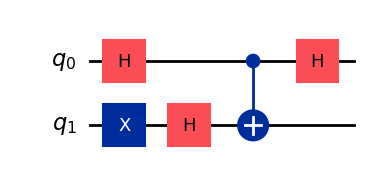

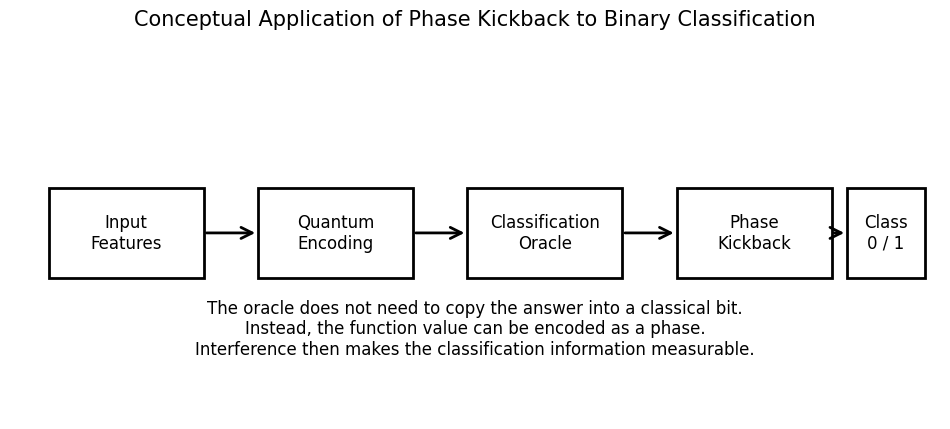

In [1]:
from qiskit import QuantumCircuit
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, FancyArrowPatch


# =========================================================
# PHASE KICKBACK DEMONSTRATION
# =========================================================

qc = QuantumCircuit(2)

# Input state
qc.h(0)

# Ancilla |1> -> |->
qc.x(1)
qc.h(1)

# Classification oracle
# Assume f(x)=x
qc.cx(0, 1)

# Interference step
qc.h(0)

print("Phase Kickback Classification Circuit")
display(qc.draw("mpl"))


# =========================================================
# SIMPLE CONCEPTUAL DIAGRAM
# =========================================================

fig, ax = plt.subplots(figsize=(12, 5))

ax.set_xlim(0, 12)
ax.set_ylim(0, 6)

# Remove axes
ax.axis("off")

# Boxes
boxes = [
    (0.5, 2.2, 2.0, 1.4, "Input\nFeatures"),
    (3.2, 2.2, 2.0, 1.4, "Quantum\nEncoding"),
    (5.9, 2.2, 2.0, 1.4, "Classification\nOracle"),
    (8.6, 2.2, 2.0, 1.4, "Phase\nKickback"),
    (10.8, 2.2, 1.0, 1.4, "Class\n0 / 1")
]

for x, y, w, h, text in boxes:
    rect = Rectangle(
        (x, y),
        w,
        h,
        fill=False,
        linewidth=2
    )
    ax.add_patch(rect)

    ax.text(
        x + w/2,
        y + h/2,
        text,
        ha="center",
        va="center",
        fontsize=12
    )


# Arrows
for i in range(len(boxes) - 1):
    x1 = boxes[i][0] + boxes[i][2]
    x2 = boxes[i+1][0]

    arrow = FancyArrowPatch(
        (x1, 2.9),
        (x2, 2.9),
        arrowstyle="->",
        mutation_scale=20,
        linewidth=2
    )

    ax.add_patch(arrow)


# Explanation
ax.text(
    6,
    1.0,
    "The oracle does not need to copy the answer into a classical bit.\n"
    "Instead, the function value can be encoded as a phase.\n"
    "Interference then makes the classification information measurable.",
    ha="center",
    fontsize=12
)

ax.set_title(
    "Conceptual Application of Phase Kickback to Binary Classification",
    fontsize=15
)

plt.show()